# XGBoost — Prediccion Alto Riesgo Anemia Ano Siguiente (v8)\n",
    "\n",
    "**Estructura:** dado un distrito en el ano `t`, predecir si sera alto riesgo en `t+1`  \n",
    "**Target:** `alto_riesgo_t1` = 1 si `prevalencia_anemia(t+1) >= 30%`  \n",
    "**Split:** train t=2020-2023 | val t=2024 | test t=2025  \n",
    "**Regularizacion:** max_depth=3, min_child_weight=40, reg_lambda=15, early stopping=50  \n",
    "**Metrica principal:** Precision | secundarias: Recall, Accuracy"

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.ticker as mticker
import seaborn as sns
import warnings
warnings.filterwarnings('ignore')

from xgboost import XGBClassifier
from sklearn.metrics import (
    precision_score, recall_score, accuracy_score,
    classification_report, confusion_matrix,
    precision_recall_curve, roc_curve, roc_auc_score,
    average_precision_score, ConfusionMatrixDisplay
)
from sklearn.preprocessing import OrdinalEncoder
from sklearn.impute import SimpleImputer
import shap

plt.rcParams['figure.dpi'] = 120
sns.set_theme(style='whitegrid')

df = pd.read_csv('../../data/clean/merged/panel_distrital_final.csv')
print(f'Shape original: {df.shape}  |  Anos: {sorted(df.anio.unique())}')

Shape original: (13148, 36)  |  Anos: [np.int64(2020), np.int64(2021), np.int64(2022), np.int64(2023), np.int64(2024), np.int64(2025), np.int64(2026)]


## 1. Construccion del dataset t -> t+1

In [2]:
UMBRAL = 0.30

target_next = df[['ubigeo', 'anio', 'prevalencia_anemia']].copy()
target_next['anio'] = target_next['anio'] - 1
target_next = target_next.rename(columns={'prevalencia_anemia': 'prev_t1'})

panel = df.merge(target_next, on=['ubigeo', 'anio'], how='inner')
panel = panel.dropna(subset=['prev_t1', 'prevalencia_anemia'])
panel['alto_riesgo_t1'] = (panel['prev_t1'] >= UMBRAL).astype(int)

print(f'Pares t->t+1: {len(panel):,}')
print()
print(panel.groupby('anio').agg(
    n=('ubigeo', 'count'),
    pct_positivo=('alto_riesgo_t1', 'mean')
).round(3))

Pares t->t+1: 11,049

         n  pct_positivo
anio                    
2020  1787         0.525
2021  1808         0.520
2022  1836         0.314
2023  1865         0.188
2024  1877         0.144
2025  1876         0.153


## 2. Features seleccionadas: union top-15 SHAP + top-10 gain, correlacion < 0.90

In [3]:
TARGET = 'alto_riesgo_t1'

# prevalencia_anemia(t) = lag legitimo — prevalencia del anio t, predice t+1
features = [
    'prevalencia_anemia',
    'altitude',
    'ninos_evaluados',
    'gasto_total',
    'pct_agua_visible',
    'area_construida_m2',
    'pct_agua_permanente',
    'personal_total',
    'superficie',
    'provincia',
    'densidad_edificios_km2',
    'pct_desnudo',
    'latitude',
    'longitude',
    'macroregion_minsa',
    'macroregion_inei',
]

cat_cols = [c for c in features if panel[c].dtype == 'object']
num_cols = [c for c in features if panel[c].dtype != 'object']

train_df = panel[panel.anio.isin([2020, 2021, 2022, 2023])]
val_df   = panel[panel.anio == 2024]
test_df  = panel[panel.anio == 2025]

print(f'Features finales: {len(features)}')
print(f'  Numericas  ({len(num_cols)}): {num_cols}')
print(f'  Categoricas ({len(cat_cols)}): {cat_cols}')
print()
print(f'Train (t=2020-2023) : {len(train_df):,}  | pos: {train_df[TARGET].mean():.1%}  | predice 2021-2024')
print(f'Val   (t=2024)      : {len(val_df):,}   | pos: {val_df[TARGET].mean():.1%}  | predice 2025')
print(f'Test  (t=2025)      : {len(test_df):,}   | pos: {test_df[TARGET].mean():.1%}  | predice 2026')

Features finales: 16
  Numericas  (13): ['prevalencia_anemia', 'altitude', 'ninos_evaluados', 'gasto_total', 'pct_agua_visible', 'area_construida_m2', 'pct_agua_permanente', 'personal_total', 'superficie', 'densidad_edificios_km2', 'pct_desnudo', 'latitude', 'longitude']
  Categoricas (3): ['provincia', 'macroregion_minsa', 'macroregion_inei']

Train (t=2020-2023) : 7,296  | pos: 38.5%  | predice 2021-2024
Val   (t=2024)      : 1,877   | pos: 14.4%  | predice 2025
Test  (t=2025)      : 1,876   | pos: 15.3%  | predice 2026


## 3. Preprocessing

In [4]:
enc = OrdinalEncoder(handle_unknown='use_encoded_value', unknown_value=-1)
imp = SimpleImputer(strategy='median')

def preprocess(train, val, test):
    Xtr = train[features].copy()
    Xva = val[features].copy()
    Xte = test[features].copy()
    Xtr[cat_cols] = enc.fit_transform(Xtr[cat_cols])
    Xva[cat_cols] = enc.transform(Xva[cat_cols])
    Xte[cat_cols] = enc.transform(Xte[cat_cols])
    Xtr[num_cols] = imp.fit_transform(Xtr[num_cols])
    Xva[num_cols] = imp.transform(Xva[num_cols])
    Xte[num_cols] = imp.transform(Xte[num_cols])
    return Xtr, Xva, Xte

X_train, X_val, X_test = preprocess(train_df, val_df, test_df)
y_train = train_df[TARGET].values
y_val   = val_df[TARGET].values
y_test  = test_df[TARGET].values

neg, pos = (y_train == 0).sum(), (y_train == 1).sum()
scale_pos = neg / pos
print(f'Nulos restantes: {X_train.isnull().sum().sum()}')
print(f'scale_pos_weight: {scale_pos:.2f}')

Nulos restantes: 0
scale_pos_weight: 1.60


## 4. Entrenamiento XGBoost

In [5]:
model = XGBClassifier(
    # --- Regularizacion mas agresiva (idea 2) ---
    n_estimators          = 1000,   # alto para que early stopping elija
    learning_rate         = 0.03,
    max_depth             = 3,      # antes 4
    subsample             = 0.70,
    colsample_bytree      = 0.70,
    min_child_weight      = 40,     # antes 15
    gamma                 = 2.0,    # antes 1.0
    reg_alpha             = 2.0,    # antes 1.0
    reg_lambda            = 15.0,   # antes 5.0
    scale_pos_weight      = scale_pos,
    eval_metric           = 'aucpr',
    # --- Early stopping sobre val (idea 1) ---
    early_stopping_rounds = 50,
    tree_method           = 'hist',
    random_state          = 42,
    n_jobs                = -1
)

model.fit(
    X_train, y_train,
    eval_set=[(X_train, y_train), (X_val, y_val)],
    verbose=100
)

print(f'\nMejor iteracion: {model.best_iteration}  |  Mejor val PR-AUC: {model.best_score:.4f}')

prob_train = model.predict_proba(X_train)[:, 1]
prob_val   = model.predict_proba(X_val)[:, 1]
prob_test  = model.predict_proba(X_test)[:, 1]

[0]	validation_0-aucpr:0.74171	validation_1-aucpr:0.50997


[100]	validation_0-aucpr:0.79168	validation_1-aucpr:0.55587


[116]	validation_0-aucpr:0.79456	validation_1-aucpr:0.55197



Mejor iteracion: 66  |  Mejor val PR-AUC: 0.5665


## 5. Threshold tuning sobre validacion (predice 2024)

Threshold optimo: 0.700


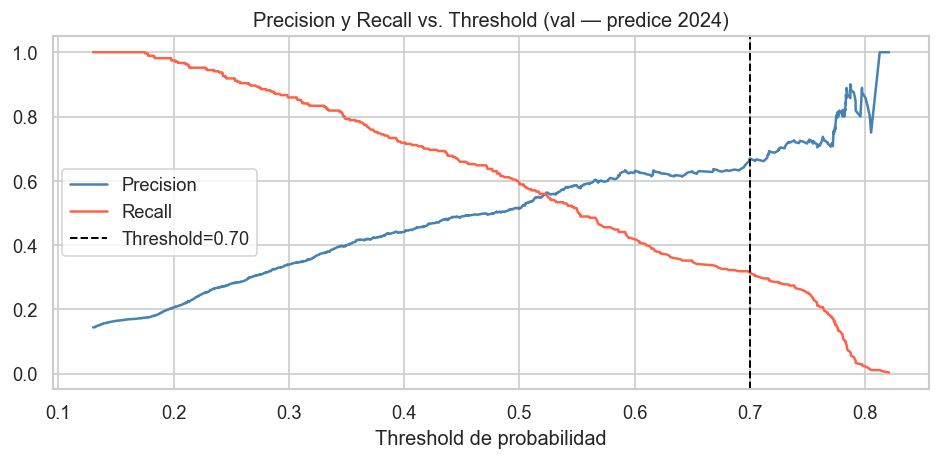

In [6]:
prec_v, rec_v, thresh_v = precision_recall_curve(y_val, prob_val)

min_recall = 0.30
mask = rec_v[:-1] >= min_recall
best_thresh = float(thresh_v[mask][np.argmax(prec_v[:-1][mask])]) if mask.any() else 0.5
print(f'Threshold optimo: {best_thresh:.3f}')

fig, ax = plt.subplots(figsize=(8, 4))
ax.plot(thresh_v, prec_v[:-1], label='Precision', color='steelblue')
ax.plot(thresh_v, rec_v[:-1],  label='Recall',    color='tomato')
ax.axvline(best_thresh, color='black', linestyle='--', lw=1.2,
           label=f'Threshold={best_thresh:.2f}')
ax.set_xlabel('Threshold de probabilidad')
ax.set_title('Precision y Recall vs. Threshold (val — predice 2024)')
ax.legend()
plt.tight_layout()
plt.savefig('fig_threshold_tuning.png', bbox_inches='tight')
plt.show()

## 6. Metricas: Precision, Recall, Accuracy

In [7]:
def evaluar(y_true, prob, thresh, split):
    pred = (prob >= thresh).astype(int)
    p  = precision_score(y_true, pred, zero_division=0)
    r  = recall_score(y_true, pred, zero_division=0)
    a  = accuracy_score(y_true, pred)
    ap = average_precision_score(y_true, prob)
    print(f'\n--- {split} (threshold={thresh:.2f}) ---')
    print(f'  Precision : {p:.4f}')
    print(f'  Recall    : {r:.4f}')
    print(f'  Accuracy  : {a:.4f}')
    print(f'  PR-AUC    : {ap:.4f}')
    return {'split': split, 'Precision': p, 'Recall': r, 'Accuracy': a, 'PR-AUC': ap}

r_train = evaluar(y_train, prob_train, best_thresh, 'Train (predice 2021-2023)')
r_val   = evaluar(y_val,   prob_val,   best_thresh, 'Val   (predice 2024)')
r_test  = evaluar(y_test,  prob_test,  best_thresh, 'Test  (predice 2025-2026)')

pred_test = (prob_test >= best_thresh).astype(int)
print('\n=== Reporte completo TEST ===')
print(classification_report(y_test, pred_test, target_names=['Bajo riesgo', 'Alto riesgo']))

pd.DataFrame([r_train, r_val, r_test]).set_index('split').round(4)


--- Train (predice 2021-2023) (threshold=0.70) ---
  Precision : 0.8151
  Recall    : 0.5354
  Accuracy  : 0.7745
  PR-AUC    : 0.7826

--- Val   (predice 2024) (threshold=0.70) ---
  Precision : 0.6693
  Recall    : 0.3148
  Accuracy  : 0.8791
  PR-AUC    : 0.5679

--- Test  (predice 2025-2026) (threshold=0.70) ---
  Precision : 0.8750
  Recall    : 0.2927
  Accuracy  : 0.8854
  PR-AUC    : 0.7087

=== Reporte completo TEST ===
              precision    recall  f1-score   support

 Bajo riesgo       0.89      0.99      0.94      1589
 Alto riesgo       0.88      0.29      0.44       287

    accuracy                           0.89      1876
   macro avg       0.88      0.64      0.69      1876
weighted avg       0.88      0.89      0.86      1876



,Precision,Recall,Accuracy,PR-AUC
split,,,,
Train (predice 2021-2023),0.8151,0.5354,0.7745,0.7826
Val (predice 2024),0.6693,0.3148,0.8791,0.5679
Test (predice 2025-2026),0.8750,0.2927,0.8854,0.7087


## 7. Confusion matrix

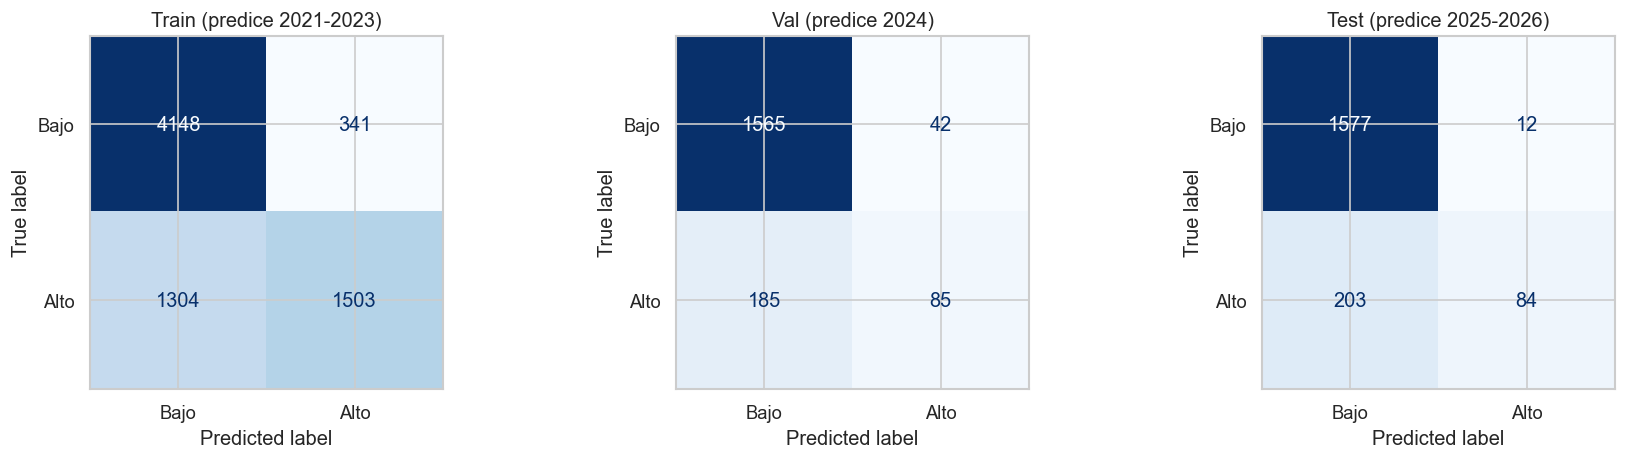

In [8]:
fig, axes = plt.subplots(1, 3, figsize=(15, 4))
for ax, y_true, prob, titulo in zip(
    axes,
    [y_train, y_val, y_test],
    [prob_train, prob_val, prob_test],
    ['Train (predice 2021-2023)', 'Val (predice 2024)', 'Test (predice 2025-2026)']
):
    pred = (prob >= best_thresh).astype(int)
    ConfusionMatrixDisplay(
        confusion_matrix(y_true, pred), display_labels=['Bajo', 'Alto']
    ).plot(ax=ax, colorbar=False, cmap='Blues')
    ax.set_title(titulo)
plt.tight_layout()
plt.savefig('fig_confusion_matrix.png', bbox_inches='tight')
plt.show()

## 8. Curvas ROC y Precision-Recall

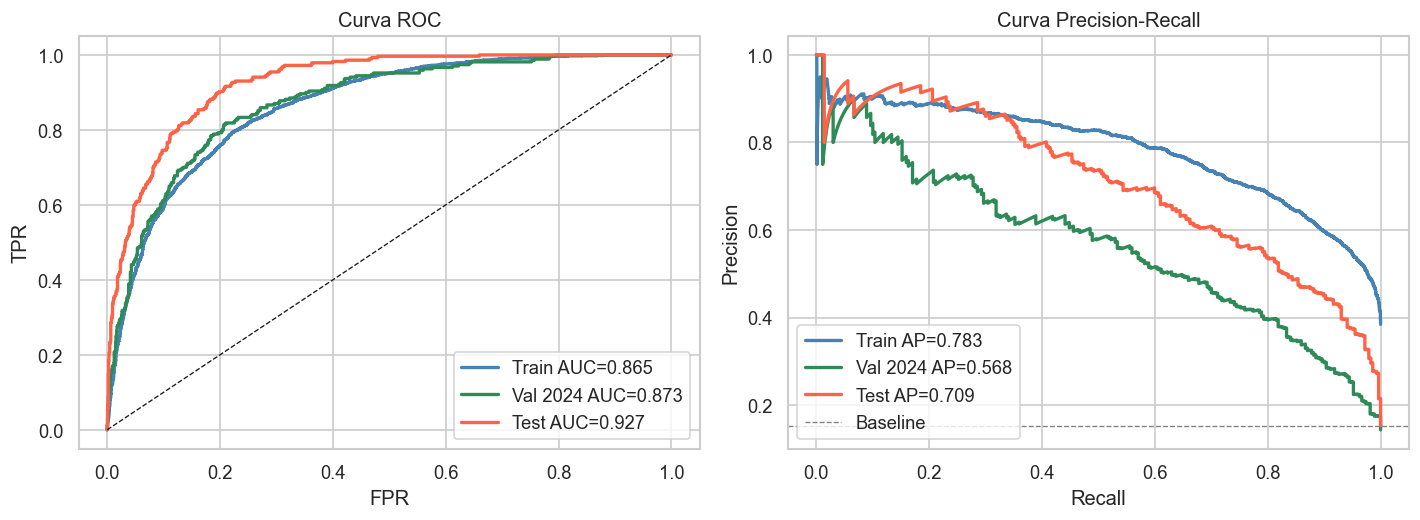

In [9]:
fig, axes = plt.subplots(1, 2, figsize=(12, 4.5))
for split, y_true, prob, color in [
    ('Train',    y_train, prob_train, 'steelblue'),
    ('Val 2024', y_val,   prob_val,   'seagreen'),
    ('Test',     y_test,  prob_test,  'tomato')
]:
    fpr, tpr, _ = roc_curve(y_true, prob)
    axes[0].plot(fpr, tpr, color=color, lw=2,
                 label=f'{split} AUC={roc_auc_score(y_true,prob):.3f}')
    prec, rec, _ = precision_recall_curve(y_true, prob)
    axes[1].plot(rec, prec, color=color, lw=2,
                 label=f'{split} AP={average_precision_score(y_true,prob):.3f}')

axes[0].plot([0,1],[0,1],'k--',lw=0.8)
axes[0].set_title('Curva ROC')
axes[0].set_xlabel('FPR'); axes[0].set_ylabel('TPR'); axes[0].legend()
axes[1].axhline(y_test.mean(), color='grey', ls='--', lw=0.8, label='Baseline')
axes[1].set_title('Curva Precision-Recall')
axes[1].set_xlabel('Recall'); axes[1].set_ylabel('Precision'); axes[1].legend()
plt.tight_layout()
plt.savefig('fig_roc_pr_curves.png', bbox_inches='tight')
plt.show()

## 9. Feature Importance XGBoost (3 metricas)

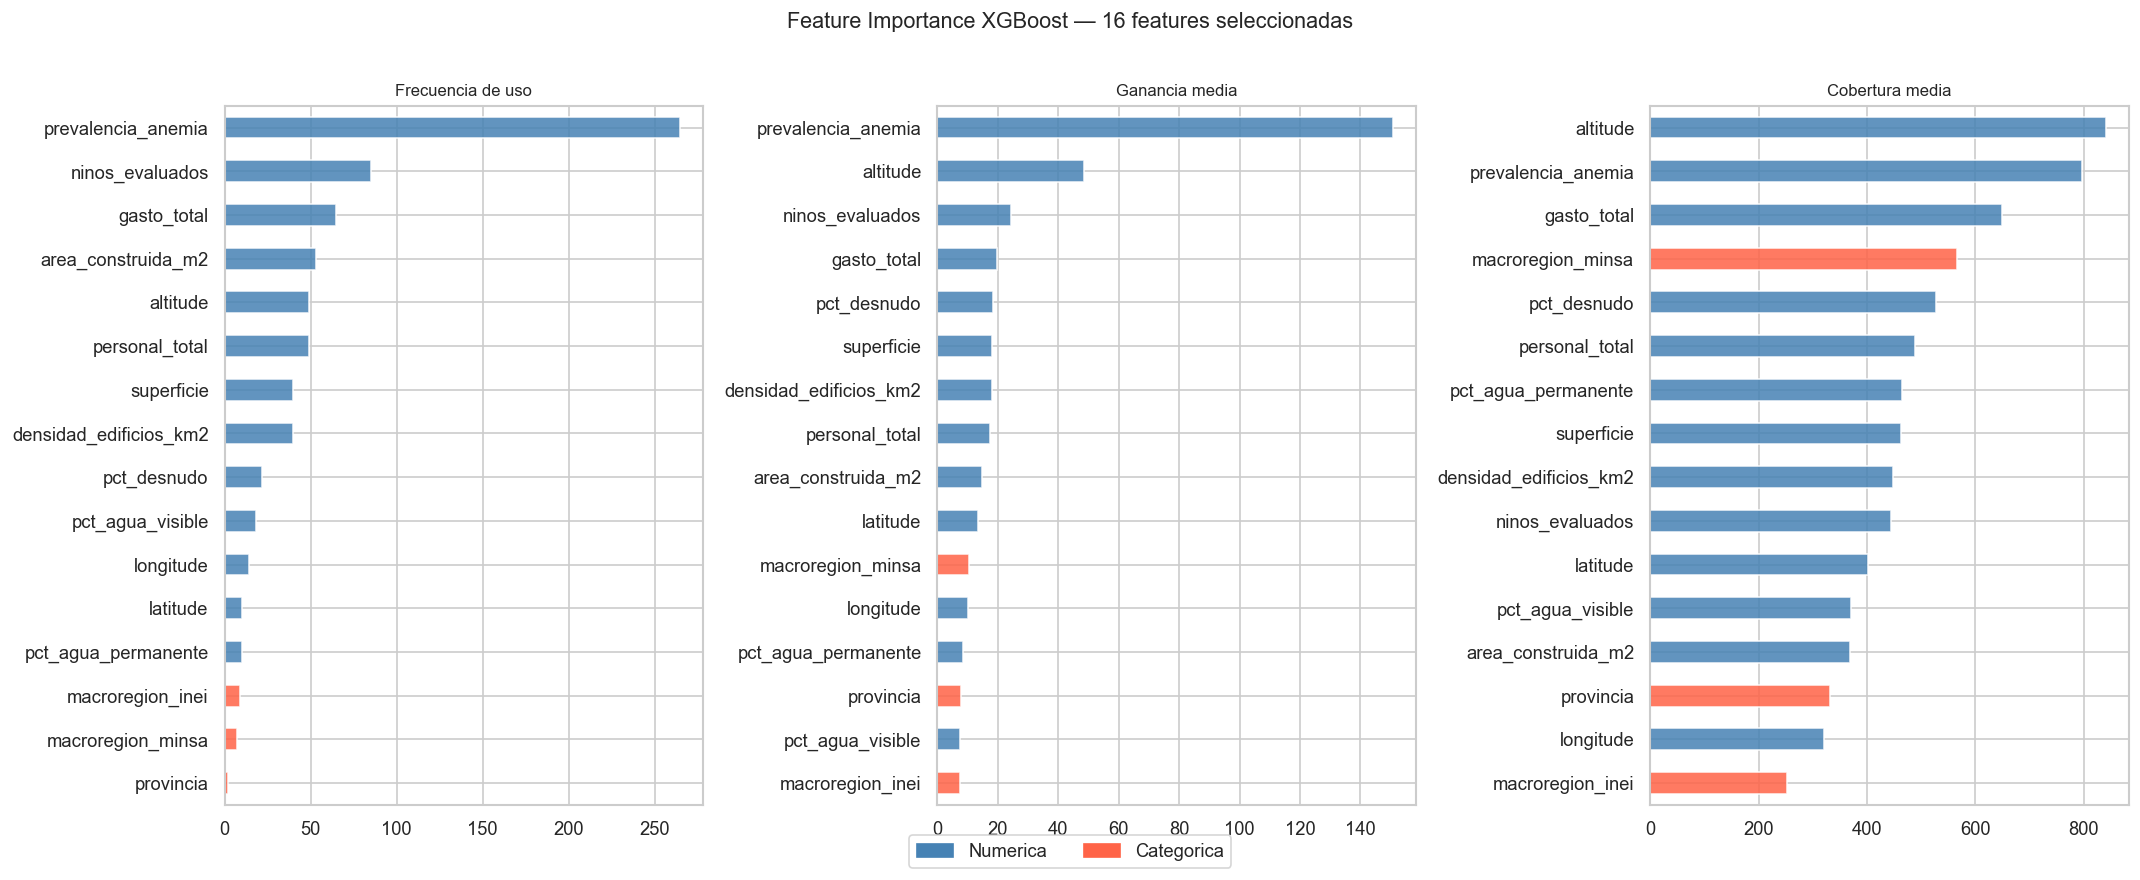

In [10]:
fmap   = {f'f{i}': f for i, f in enumerate(features)}
labels = {'weight': 'Frecuencia de uso', 'gain': 'Ganancia media', 'cover': 'Cobertura media'}

fig, axes = plt.subplots(1, 3, figsize=(18, 7))
for ax, itype in zip(axes, ['weight', 'gain', 'cover']):
    scores    = model.get_booster().get_score(importance_type=itype)
    imp_named = pd.Series({fmap.get(k,k): v for k,v in scores.items()}).sort_values(ascending=True)
    colors    = ['tomato' if f in cat_cols else 'steelblue' for f in imp_named.index]
    imp_named.plot(kind='barh', ax=ax, color=colors, alpha=0.85)
    ax.set_title(labels[itype], fontsize=10)

from matplotlib.patches import Patch
fig.legend(
    handles=[Patch(color='steelblue', label='Numerica'), Patch(color='tomato', label='Categorica')],
    loc='lower center', ncol=2, bbox_to_anchor=(0.5, -0.02)
)
fig.suptitle('Feature Importance XGBoost — 16 features seleccionadas', fontsize=13, y=1.01)
plt.tight_layout()
plt.savefig('fig_feature_importance.png', bbox_inches='tight')
plt.show()

## 10. SHAP — interpretabilidad sobre test

In [11]:
explainer   = shap.TreeExplainer(model)
shap_values = explainer.shap_values(X_test)

shap_final = pd.Series(
    np.abs(shap_values).mean(axis=0), index=features
).sort_values(ascending=False)

print('SHAP importancia final (test):')
print(shap_final.round(4).to_string())

SHAP importancia final (test):
prevalencia_anemia        1.0054
ninos_evaluados           0.1267
altitude                  0.1158
personal_total            0.0578
area_construida_m2        0.0362
densidad_edificios_km2    0.0284
gasto_total               0.0280
superficie                0.0274
pct_desnudo               0.0191
longitude                 0.0053
macroregion_inei          0.0052
pct_agua_visible          0.0043
latitude                  0.0041
macroregion_minsa         0.0007
pct_agua_permanente       0.0000
provincia                 0.0000


### 10a. Beeswarm

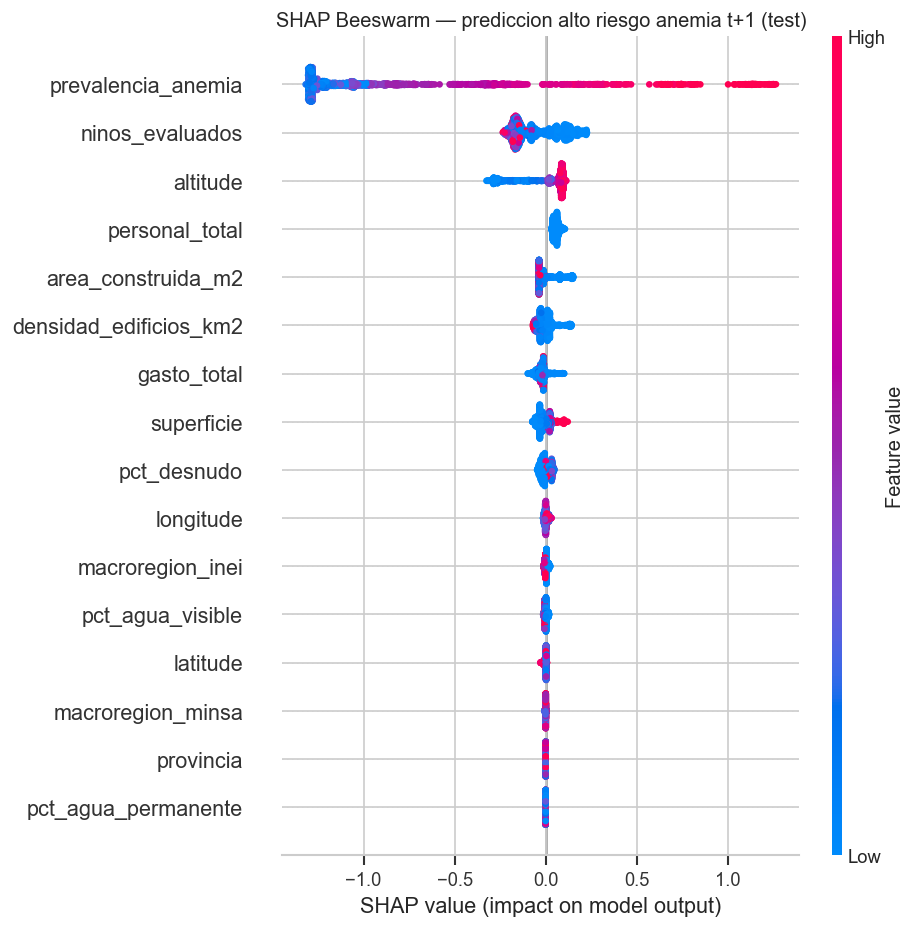

In [12]:
shap.summary_plot(shap_values, X_test, feature_names=features, max_display=16, show=False)
plt.title('SHAP Beeswarm — prediccion alto riesgo anemia t+1 (test)')
plt.tight_layout()
plt.savefig('fig_shap_beeswarm.png', bbox_inches='tight')
plt.show()

### 10b. Bar SHAP

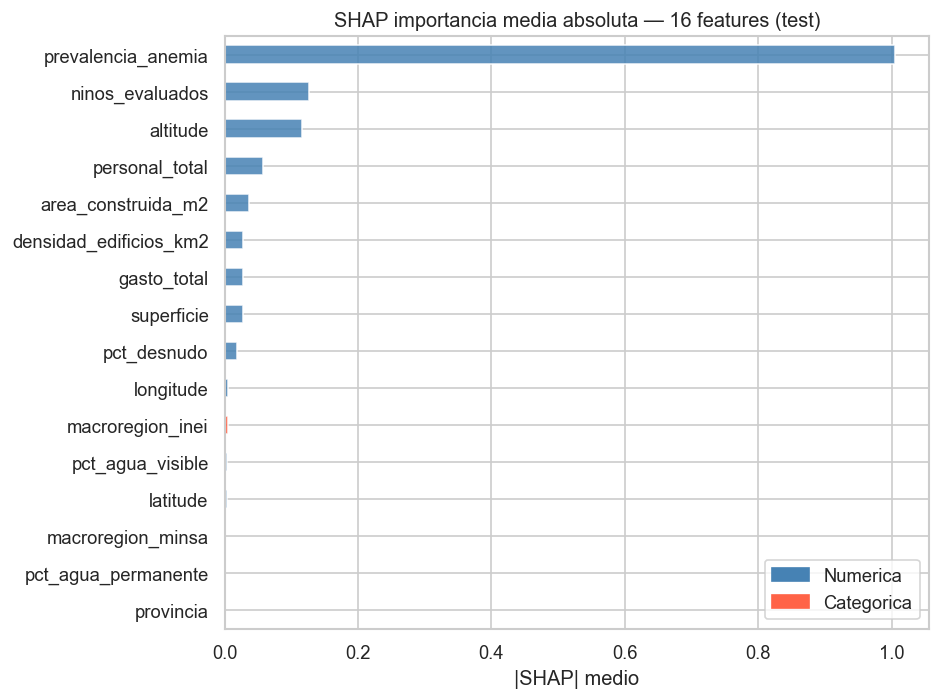

In [13]:
top_shap = shap_final.sort_values(ascending=True)
colors   = ['tomato' if f in cat_cols else 'steelblue' for f in top_shap.index]

fig, ax = plt.subplots(figsize=(8, 6))
top_shap.plot(kind='barh', ax=ax, color=colors, alpha=0.85)
ax.set_title('SHAP importancia media absoluta — 16 features (test)')
ax.set_xlabel('|SHAP| medio')
from matplotlib.patches import Patch
ax.legend(handles=[
    Patch(color='steelblue', label='Numerica'),
    Patch(color='tomato',    label='Categorica')
], loc='lower right')
plt.tight_layout()
plt.savefig('fig_shap_bar.png', bbox_inches='tight')
plt.show()

### 10c. Dependence plots — top 4 features

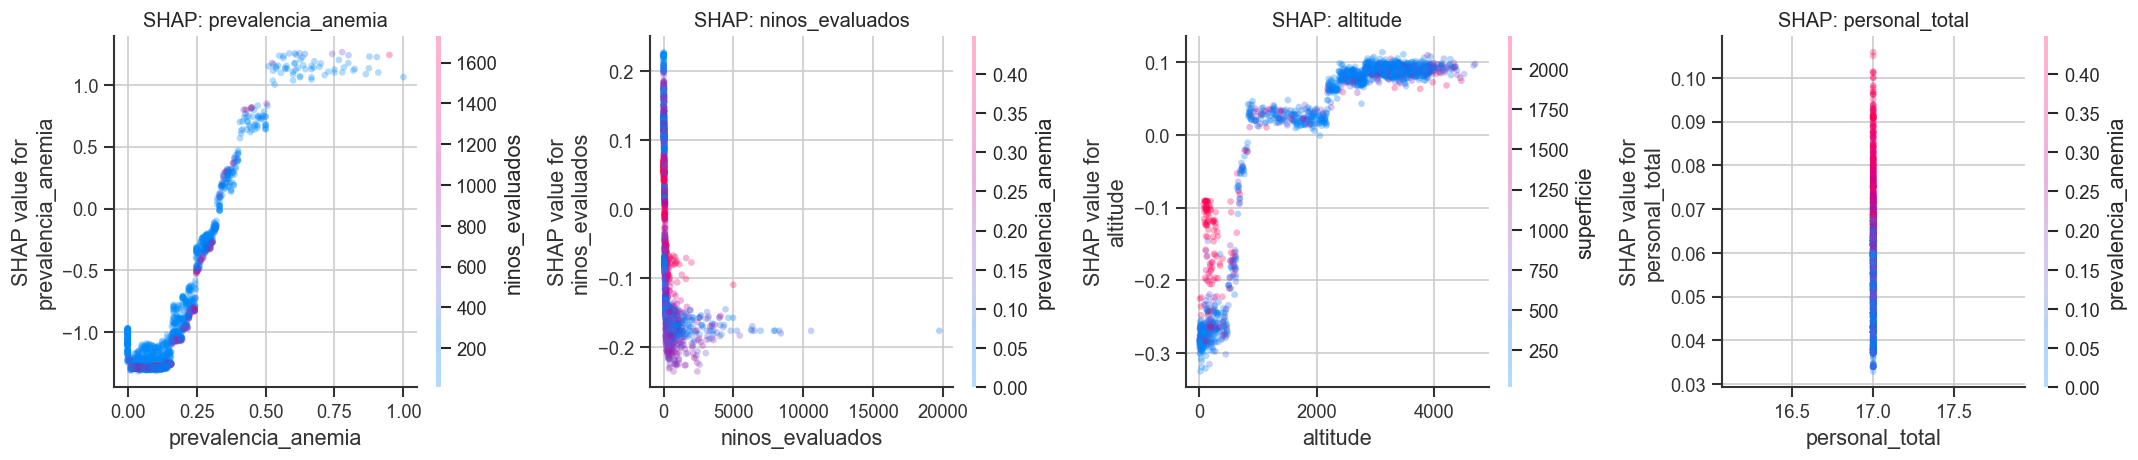

In [14]:
top4 = shap_final.head(4).index.tolist()
fig, axes = plt.subplots(1, 4, figsize=(18, 4))
for ax, feat in zip(axes, top4):
    shap.dependence_plot(feat, shap_values, X_test,
                         feature_names=features, ax=ax, show=False, alpha=0.3)
    ax.set_title(f'SHAP: {feat}')
plt.tight_layout()
plt.savefig('fig_shap_dependence.png', bbox_inches='tight')
plt.show()

### 10d. Waterfall — falso positivo y falso negativo

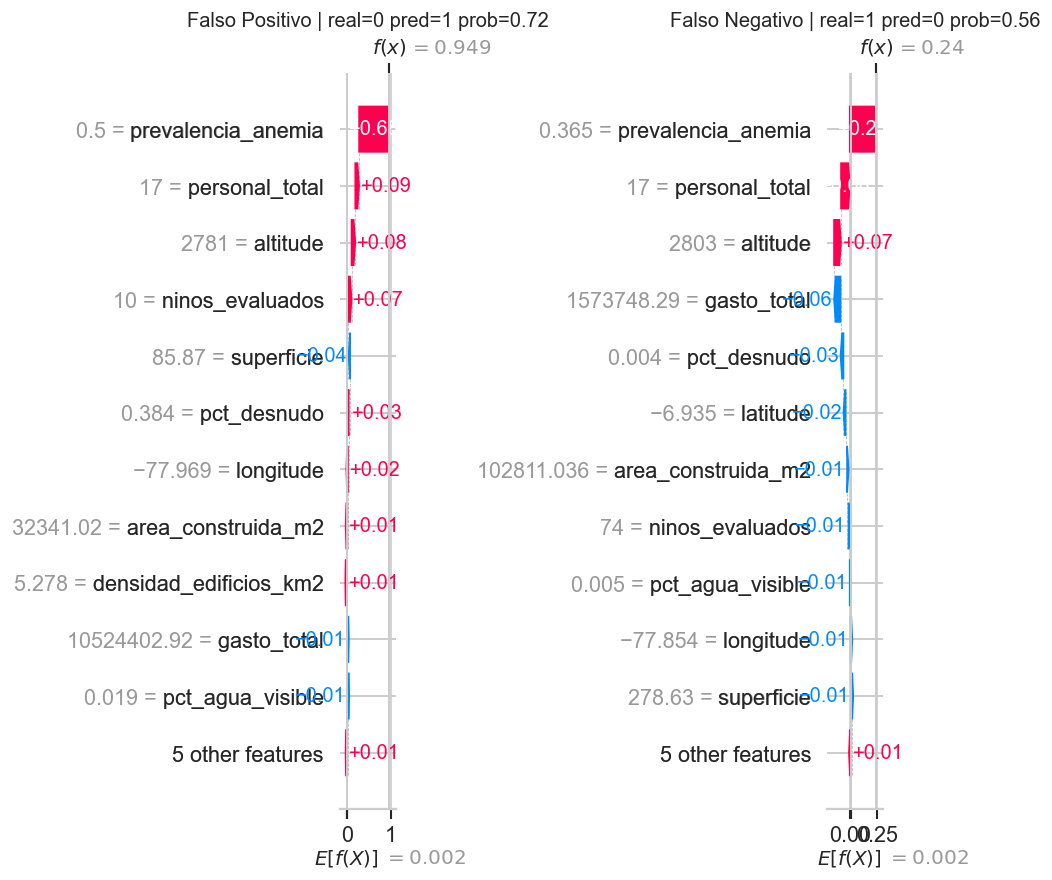

In [15]:
pred_test_bin = (prob_test >= best_thresh).astype(int)
fp_idx = np.where((pred_test_bin == 1) & (y_test == 0))[0]
fn_idx = np.where((pred_test_bin == 0) & (y_test == 1))[0]

fig, axes = plt.subplots(1, 2, figsize=(16, 5))
for ax, idx, titulo in [
    (axes[0], fp_idx[0] if len(fp_idx) else 0, 'Falso Positivo'),
    (axes[1], fn_idx[0] if len(fn_idx) else 1, 'Falso Negativo')
]:
    exp = shap.Explanation(
        values=shap_values[idx], base_values=explainer.expected_value,
        data=X_test.iloc[idx].values, feature_names=features
    )
    plt.sca(ax)
    shap.waterfall_plot(exp, max_display=12, show=False)
    ax.set_title(f'{titulo} | real={y_test[idx]} pred={pred_test_bin[idx]} prob={prob_test[idx]:.2f}')
plt.tight_layout()
plt.savefig('fig_shap_waterfall.png', bbox_inches='tight')
plt.show()

## 11. Metricas por ano predicho (test)

               Precision  Recall  Accuracy  PR-AUC
anio_predicho                                     
2026               0.875  0.2927    0.8854  0.7087


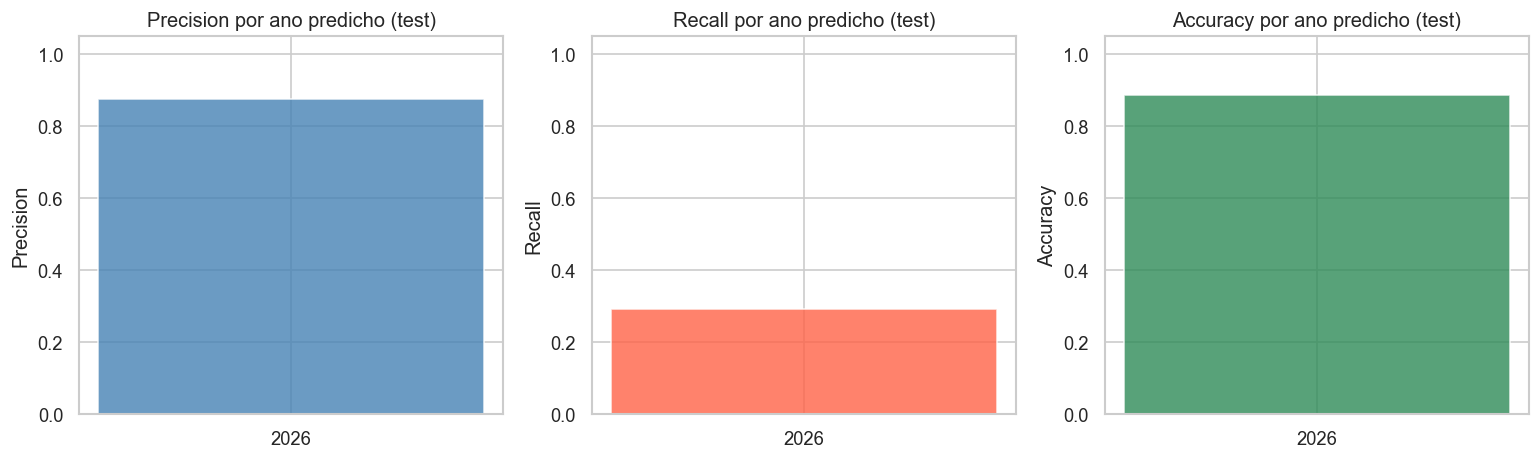

In [16]:
test_res = test_df[['anio', TARGET]].copy().reset_index(drop=True)
test_res['prob'] = prob_test
test_res['pred'] = pred_test_bin
test_res['anio_predicho'] = test_res['anio'] + 1

by_year = test_res.groupby('anio_predicho').apply(
    lambda g: pd.Series({
        'Precision': precision_score(g[TARGET], g['pred'], zero_division=0),
        'Recall'   : recall_score(g[TARGET], g['pred'], zero_division=0),
        'Accuracy' : accuracy_score(g[TARGET], g['pred']),
        'PR-AUC'   : average_precision_score(g[TARGET], g['prob'])
    })
).round(4)

print(by_year)

fig, axes = plt.subplots(1, 3, figsize=(13, 4))
for ax, col, c in zip(axes, ['Precision','Recall','Accuracy'], ['steelblue','tomato','seagreen']):
    ax.bar(by_year.index.astype(str), by_year[col], color=c, alpha=0.8)
    ax.set_title(f'{col} por ano predicho (test)')
    ax.set_ylim(0, 1.05)
    ax.set_ylabel(col)
plt.tight_layout()
plt.savefig('fig_metricas_por_anio.png', bbox_inches='tight')
plt.show()